# Missing and spurious interactions and the reconstruction of complex networks

---

**Students**
* Gabriele Bellavia (Badge No. )
* Sofia Di Lucia (Badge No. 2149752)

**Academic Year:** 2025–2026

---

- [Ref article](https://www.pnas.org/doi/10.1073/pnas.0908366106)
- I dataset citati dovrebbero essere questi:
    1. [karate club (23)](https://networkrepository.com/soc-karate.php)
    2. [dolphins (24)](https://networkrepository.com/dolphins.php)
    3. [air transportation network of Eastern Europe (25)](https://www.oag.com/flight-data-sets)
    4. [Caenorhabditis elegans (26)](http://konect.cc/networks/dimacs10-celegansneural/)
    5. [metabolic network of Escherichia coli (27, 28)](http://bigg.ucsd.edu/models/iJR904)
- Altri dataset:
    1. [SNAP](https://snap.stanford.edu/data/#socnets)
    2. [Network Repository](https://networkrepository.com/)
- Software and libraries:
    1. [igraph](https://igraph.org/)
    2. [networkx](https://networkx.org/en/)
    3. [graphtool](https://graph-tool.skewed.de/)
    4. [Gephi](https://gephi.org/)

## Karate Club network: missing and spurious interaction analysis

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import math as m
import copy as c

np.random.seed(123)

## Inspecting network

We start to work with Zachary Karate club network, which is a small, non-directed network. The network is already in networkx package, thus we consider it as the true network.

We want to work with three distinct objects: the true network, the observed one (obtained by removing random links) and the set of randomly removed links.

Graph named "Zachary's Karate Club" with 34 nodes and 78 edges


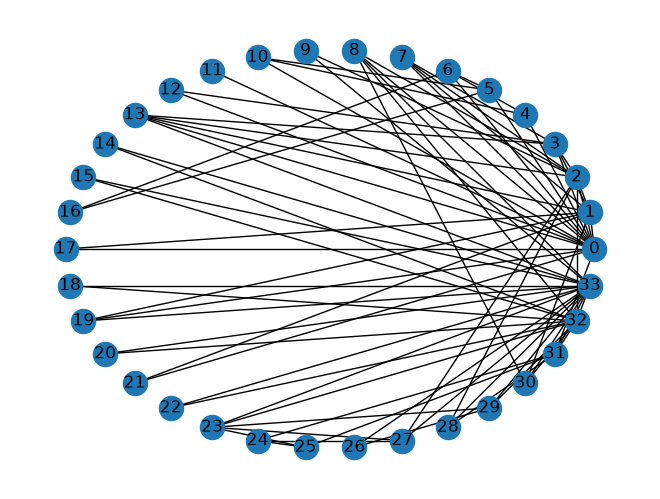

In [75]:
G = nx.karate_club_graph()
print(G)
nx.draw_circular(G, with_labels=True)
plt.show()

In [3]:
#list(G.nodes)

We want to work with unweighted networks, thus we neglect the weights.

In [76]:
AT = nx.adjacency_matrix(G, weight=None).toarray()

### Generating hypothetical observation

TO DO: confermare che tra i nuovi link non consideriamo self-loop (ovvero che possiamo escludere la diagonale)

In [77]:
AO = AT.copy()
prob = 0.2 #remove probability 20%

# we work on the upper diagonal with offset k=1 (we exclude the diagonal itself)
i_up, j_up = np.triu_indices_from(AT, k=1)

links = np.where(AT[i_up, j_up]==1)[0]
nolinks = np.where(AT[i_up, j_up]==0)[0]
rand_link = int(round(prob*len(links)))

remove = np.random.choice(links, size=rand_link, replace=False)
add = np.random.choice(nolinks, size=rand_link, replace=False)

for idx in remove:
    i, j = i_up[idx], j_up[idx]
    AO[i,j]=0
    AO[j,i]=0

for idx in add:
    i, j = i_up[idx], j_up[idx]
    AO[i,j]=1
    AO[j,i]=1

AO_G = nx.from_numpy_array(AO)

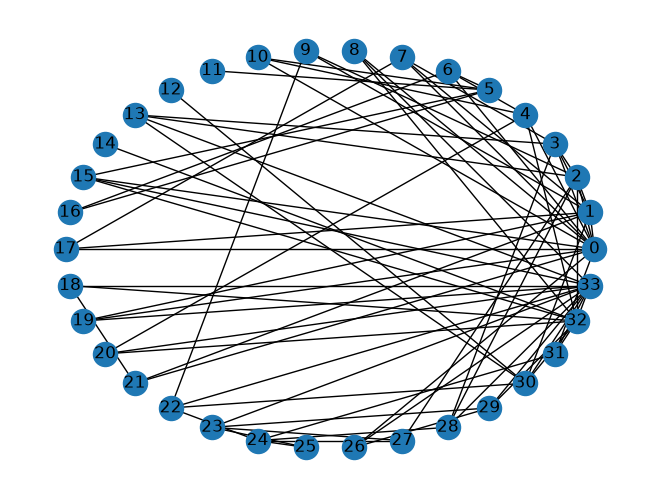

In [78]:
nx.draw_circular(nx.from_numpy_array(AO), with_labels=True)

## Metropolis Estimation

We start by placing each of the N nodes in a group, which we choose
with uniform probability from a set of N possible groups (that is, there are
as many groups as nodes). In general, some of these N groups will be empty
after the initial node assignment

In [106]:
# creating the N possible groups
N = len(G.nodes)

# group_of[i] = group assigned to i
group_of = np.random.randint(0, N, size=N)

# groups[a] = set of nodes in group a
groups = [set() for i in range(N)]

for node in range(N):
    groups[group_of[node]].add(node)

At each step we select a random node and attempt to move it to a randomly selected group:
- if $\Delta H \le 0 \rightarrow$ we accept the move
- if $\Delta H \ge 0 \rightarrow$ we accep the move with $P = e^{- \Delta H}$
with

$$H(P) = \sum_{\alpha \le \beta} \Big[\ln(r_{\alpha \beta}+1) + \ln\binom{r_{\alpha \beta}}{l^O_{\alpha \beta}} \Big]
$$
where:
- $\alpha$ and $\beta$ are groups
- $r_{\alpha \beta}$ is the maximum possible number of links between $\alpha$ and $\beta$
- $l^O_{\alpha \beta}$ is the number of links in the observed network between $\alpha$ and $\beta$

In [80]:
# function to calculate r_ab
def compute_r_ab(groups, alpha, beta):
    alpha_size = len(groups[alpha])
    beta_size = len(groups[beta])
    if(alpha==beta):
        return  alpha_size*(alpha_size-1) // 2
    else:
        return alpha_size*beta_size

In [81]:
# function to calculate lO_ab
def compute_lO_ab(groups, alpha, beta):
    lO_ab = 0
    if alpha == beta:
        nodes = list(groups[alpha])

        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                if AO_G.has_edge(nodes[i], nodes[j]):
                    lO_ab += 1
    else:
        for i in groups[alpha]:
            for j in groups[beta]:
                if AO_G.has_edge(i, j):
                    lO_ab += 1
    return lO_ab

In [82]:
# function to compute H(P)
def compute_HP(groups):
    sum_ab = 0
    for alpha in range(N):
        for beta in range(alpha, N):
            r_ab = compute_r_ab(groups, alpha, beta)
            lO_ab = compute_lO_ab(groups, alpha, beta)
            f_ab = (m.log(r_ab + 1) + m.log(m.comb(r_ab, lO_ab)))
            sum_ab += f_ab

    return sum_ab

TO DO: beta is the proposed move group, VEDERE MEGLIO CASO beta = alpha

In [107]:
H_values = []

H_old = compute_HP(groups)

for step in range(20000):
    rand_node = np.random.randint(0, N)
    alpha = group_of[rand_node]     # current group
    beta = np.random.randint(0, N)   # proposed group
    while(beta == alpha): beta = np.random.randint(0, N)
    #print(f'Selected node: {rand_node}. From group {alpha} move to group {beta}')
    groups[alpha].remove(rand_node)
    groups[beta].add(rand_node)
    group_of[rand_node] = beta
    H_new = compute_HP(groups)
    DH = H_new - H_old
    if(DH < 0):
        H_old = H_new   # accept
    elif(m.exp(-DH)>np.random.uniform(0,1)):
        H_old = H_new   # accept
    else:   # reject
        groups[beta].remove(rand_node)
        groups[alpha].add(rand_node)
        group_of[rand_node] = alpha

    H_values.append(H_old)

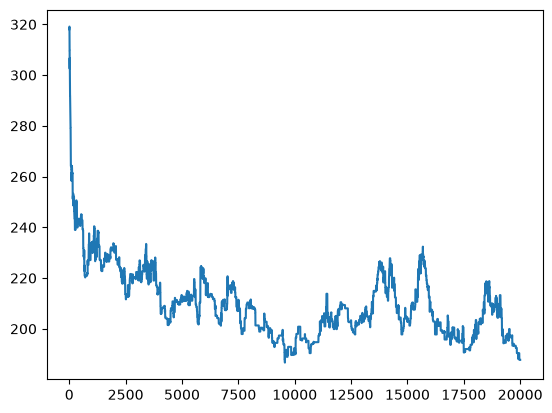

In [108]:
# checking that H has stabilized
plt.plot(H_values)

In [ ]:
#Next steps: sampling, steady state, burn in, fluctuations, ecc.

(pag.2 article):<br>
1. we assume that each of these networks is the “true” network $A^T$ and is error free
2. We then generate hypothetical observations $A^O$ by adding or removing random connections from $A^T$
3. We evaluate the ability of our approach to recover the features of the true network

- **missing(\spurious) interactions**:
1. we generate observed networks $A^O$ by removing(\adding) random links from the true network $A^T$
2. We then estimate the link reliability $R^L_{ij}$ for each of these false negatives ($A^O_{ij} = 0$ and $A^T_{ij} = 1$), as well as for the
true negatives ($A^O_{ij} = 0$ and $A^T_{ij} = 0$) (\spurious: false positive ($A^O_{ij} = 1$ and $A^T_{ij} = 0$) is ranked lower than a true positive ($A^O_{ij} = 1$ and $A^T_{ij} = 1$).)
3. We measure the algorithm’s ability to identify missing interactions by ranking the reliabilities (in decreasing order) and calculating the probability that a false negative has a higher ranking than a true negative.